In [2]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

GDP_PATH = "/Users/tonytony/Final Project/Data/Raw/gdp.csv"
LIFE_PATH = "/Users/tonytony/Final Project/Data/Raw/life_expectancy.csv"
POP_PATH = "/Users/tonytony/Final Project/Data/Raw/population.csv"
META_PATH = "/Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv"

print("GDP:", GDP_PATH)
print("Life Expectancy:", LIFE_PATH)
print("Population:", POP_PATH)
print("Metadata:", META_PATH)


GDP: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Life Expectancy: /Users/tonytony/Final Project/Data/Raw/life_expectancy.csv
Population: /Users/tonytony/Final Project/Data/Raw/population.csv
Metadata: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv


In [3]:
meta_df = pd.read_csv(META_PATH)

region_map = meta_df[[
    "Country Code",
    "World Bank Region"
]].copy().rename(columns={
    "Country Code": "country_code",
    "World Bank Region": "wb_region"
})

region_map["country_type"] = np.where(
    region_map["wb_region"].astype(str).str.strip().eq("Aggregates"),
    "Aggregate",
    "Country/Territory"
)

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    year_cols = [col for col in df.columns if str(col).isdigit()]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    return df

def to_long(df, value_name):
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name="year",
        value_name=value_name
    ).rename(columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    })

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("int64")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

def add_region_info(long_df):
    merged = long_df.merge(region_map, on="country_code", how="left")
    merged = merged[merged["country_type"] == "Country/Territory"].copy()
    return merged

def forecast_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2
    }

print("Helper functions are ready")
region_map.head()


Helper functions are ready


,country_code,wb_region,country_type
0,ABW,Latin America & Caribbean,Country/Territory
1,AFE,Aggregates,Aggregate
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory
3,AFR,Aggregates,Aggregate
4,AFW,Aggregates,Aggregate


In [4]:
gdp_long = add_region_info(to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"))
life_long = add_region_info(to_long(load_wdi(LIFE_PATH), "life_expectancy_years"))
pop_long = add_region_info(to_long(load_wdi(POP_PATH), "population_total"))

gdp_long = gdp_long[(gdp_long["gdp_per_capita_usd"].notna()) & (gdp_long["gdp_per_capita_usd"] > 0)].copy()
life_long = life_long[life_long["life_expectancy_years"].notna()].copy()
pop_long = pop_long[(pop_long["population_total"].notna()) & (pop_long["population_total"] > 0)].copy()

print("GDP long shape:", gdp_long.shape, "| latest year:", int(gdp_long["year"].max()))
print("Life long shape:", life_long.shape, "| latest year:", int(life_long["year"].max()))
print("Population long shape:", pop_long.shape, "| latest year:", int(pop_long["year"].max()))


GDP long shape: (11569, 8) | latest year: 2024
Life long shape: (13854, 8) | latest year: 2023
Population long shape: (14075, 8) | latest year: 2024


In [5]:
model_plan = pd.DataFrame({
    "Dataset": ["GDP", "Life Expectancy", "Population"],
    "Models Used": [
        "Naive, AutoReg(lags=3), ARIMA(1,1,1)",
        "Naive, AutoReg(lags=3)",
        "Naive, AutoReg(lags=3)"
    ],
    "Reason": [
        "GDP is more volatile, so ARIMA is added as a stronger time-series benchmark.",
        "Life expectancy is smoother and more trend-driven, so Naive + AutoReg is sufficient.",
        "Population is highly persistent and smooth, so Naive + AutoReg is appropriate."
    ]
})

model_plan


,Dataset,Models Used,Reason
0,GDP,"Naive, AutoReg(lags=3), ARIMA(1,1,1)","GDP is more volatile, so ARIMA is added as a s..."
1,Life Expectancy,"Naive, AutoReg(lags=3)",Life expectancy is smoother and more trend-dri...
2,Population,"Naive, AutoReg(lags=3)","Population is highly persistent and smooth, so..."


In [6]:
def one_step_walk_forward_forecast(series_values, model_name, lags=3, arima_order=(1, 1, 1), test_years=5):
    values = list(pd.Series(series_values).astype(float).values)

    train_values = values[:-test_years]
    test_values = values[-test_years:]

    history = train_values.copy()
    preds = []

    for actual in test_values:
        if model_name == "Naive":
            pred = history[-1]

        elif model_name == "AutoReg":
            train_series = pd.Series(history, dtype=float)
            fit = AutoReg(train_series, lags=lags, old_names=False, trend="c").fit()
            pred = float(fit.predict(start=len(train_series), end=len(train_series)).iloc[0])

        elif model_name == "ARIMA":
            train_series = pd.Series(history, dtype=float)
            fit = ARIMA(
                train_series,
                order=arima_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            pred = float(fit.forecast(steps=1).iloc[0])

        else:
            raise ValueError(f"Unknown model: {model_name}")

        preds.append(pred)
        history.append(actual)

    return np.array(test_values, dtype=float), np.array(preds, dtype=float)

def run_forecasting_experiment(
    long_df,
    value_col,
    dataset_name,
    models_to_use,
    lags=3,
    arima_order=(1, 1, 1),
    test_years=5,
    min_obs=20
):
    all_predictions = []
    skipped_rows = []

    grouped = long_df[["country_name", "country_code", "year", value_col]].dropna().groupby("country_code")

    for country_code, group in grouped:
        group = group.sort_values("year").copy()

        if len(group) < max(min_obs, test_years + lags + 2):
            skipped_rows.append({
                "Dataset": dataset_name,
                "country_code": country_code,
                "country_name": group["country_name"].iloc[0],
                "reason": "too_few_observations"
            })
            continue

        years_test = group["year"].iloc[-test_years:].values
        values = group[value_col].values
        country_name = group["country_name"].iloc[0]

        for model_name in models_to_use:
            try:
                actual, predicted = one_step_walk_forward_forecast(
                    series_values=values,
                    model_name=model_name,
                    lags=lags,
                    arima_order=arima_order,
                    test_years=test_years
                )

                temp = pd.DataFrame({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "country_code": country_code,
                    "country_name": country_name,
                    "year": years_test,
                    "actual": actual,
                    "predicted": predicted
                })
                all_predictions.append(temp)

            except Exception as e:
                skipped_rows.append({
                    "Dataset": dataset_name,
                    "country_code": country_code,
                    "country_name": country_name,
                    "reason": f"{model_name}: {str(e)}"
                })

    pred_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    skipped_df = pd.DataFrame(skipped_rows)

    summary_rows = []
    if not pred_df.empty:
        for model_name, temp in pred_df.groupby("Model"):
            metrics = forecast_metrics(temp["actual"], temp["predicted"])
            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                **metrics,
                "n_predictions": len(temp),
                "n_countries_modeled": temp["country_code"].nunique()
            })

    summary_df = pd.DataFrame(summary_rows)
    return pred_df, summary_df, skipped_df

print("Forecast engine is ready")


Forecast engine is ready


In [7]:
gdp_predictions, gdp_summary, gdp_skipped = run_forecasting_experiment(
    long_df=gdp_long,
    value_col="gdp_per_capita_usd",
    dataset_name="GDP",
    models_to_use=["Naive", "AutoReg", "ARIMA"],
    lags=3,
    arima_order=(1, 1, 1),
    test_years=5,
    min_obs=20
)

print("GDP summary")
display(gdp_summary.round(4))

print("GDP skipped rows:", gdp_skipped.shape[0])
gdp_predictions.head()


GDP summary


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,GDP,ARIMA,1908.6863,4692.2074,10.1958,0.9766,1045,209
1,GDP,AutoReg,1885.5361,4595.3474,10.2668,0.9776,1045,209
2,GDP,Naive,1780.4856,4230.7492,9.6465,0.9810,1045,209


GDP skipped rows: 5


,Dataset,Model,country_code,country_name,year,actual,predicted
0,GDP,Naive,ABW,Aruba,2020,22759.807175,30645.890602
1,GDP,Naive,ABW,Aruba,2021,26749.329609,22759.807175
2,GDP,Naive,ABW,Aruba,2022,30975.998912,26749.329609
3,GDP,Naive,ABW,Aruba,2023,35718.753119,30975.998912
4,GDP,Naive,ABW,Aruba,2024,39498.594129,35718.753119


In [11]:
life_predictions, life_summary, life_skipped = run_forecasting_experiment(
    long_df=life_long,
    value_col="life_expectancy_years",
    dataset_name="Life Expectancy",
    models_to_use=["Naive", "AutoReg"],
    lags=3,
    test_years=5,
    min_obs=20
)

print("Life Expectancy summary")
display(life_summary.round(4))

print("Life skipped rows:", life_skipped.shape[0])
life_predictions.head()


Life Expectancy summary


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,Life Expectancy,AutoReg,1.2300,2.4302,1.8474,0.8991,1085,217
1,Life Expectancy,Naive,0.9655,2.1143,1.4893,0.9237,1085,217


Life skipped rows: 0


,Dataset,Model,country_code,country_name,year,actual,predicted
0,Life Expectancy,Naive,ABW,Aruba,2019,76.019,75.880
1,Life Expectancy,Naive,ABW,Aruba,2020,75.406,76.019
2,Life Expectancy,Naive,ABW,Aruba,2021,73.655,75.406
3,Life Expectancy,Naive,ABW,Aruba,2022,76.226,73.655
4,Life Expectancy,Naive,ABW,Aruba,2023,76.353,76.226


In [9]:
pop_predictions, pop_summary, pop_skipped = run_forecasting_experiment(
    long_df=pop_long,
    value_col="population_total",
    dataset_name="Population",
    models_to_use=["Naive", "AutoReg"],
    lags=3,
    test_years=5,
    min_obs=20
)

print("Population summary")
display(pop_summary.round(4))

print("Population skipped rows:", pop_skipped.shape[0])
pop_predictions.head()


Population summary


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,Population,AutoReg,71337.5562,3.173279e+05,0.4142,1.0000,1085,217
1,Population,Naive,379334.9972,1.115824e+06,1.3909,0.9999,1085,217


Population skipped rows: 0


,Dataset,Model,country_code,country_name,year,actual,predicted
0,Population,Naive,ABW,Aruba,2020,108587.0,109203.0
1,Population,Naive,ABW,Aruba,2021,107700.0,108587.0
2,Population,Naive,ABW,Aruba,2022,107310.0,107700.0
3,Population,Naive,ABW,Aruba,2023,107359.0,107310.0
4,Population,Naive,ABW,Aruba,2024,107995.0,107359.0


In [12]:
all_summaries = pd.concat([gdp_summary, life_summary, pop_summary], ignore_index=True)
all_summaries.round(4)


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,GDP,ARIMA,1908.6863,4.692207e+03,10.1958,0.9766,1045,209
1,GDP,AutoReg,1885.5361,4.595347e+03,10.2668,0.9776,1045,209
2,GDP,Naive,1780.4856,4.230749e+03,9.6465,0.9810,1045,209
3,Life Expectancy,AutoReg,1.2300,2.430200e+00,1.8474,0.8991,1085,217
4,Life Expectancy,Naive,0.9655,2.114300e+00,1.4893,0.9237,1085,217
5,Population,AutoReg,71337.5562,3.173279e+05,0.4142,1.0000,1085,217
6,Population,Naive,379334.9972,1.115824e+06,1.3909,0.9999,1085,217


In [13]:
all_predictions = pd.concat([gdp_predictions, life_predictions, pop_predictions], ignore_index=True)
all_predictions.head(15)


,Dataset,Model,country_code,country_name,year,actual,predicted
0,GDP,Naive,ABW,Aruba,2020,22759.807175,30645.890602
1,GDP,Naive,ABW,Aruba,2021,26749.329609,22759.807175
2,GDP,Naive,ABW,Aruba,2022,30975.998912,26749.329609
3,GDP,Naive,ABW,Aruba,2023,35718.753119,30975.998912
4,GDP,Naive,ABW,Aruba,2024,39498.594129,35718.753119
5,GDP,AutoReg,ABW,Aruba,2020,22759.807175,30522.660040
6,GDP,AutoReg,ABW,Aruba,2021,26749.329609,23152.900109
7,GDP,AutoReg,ABW,Aruba,2022,30975.998912,30855.590673
8,GDP,AutoReg,ABW,Aruba,2023,35718.753119,26985.141163
9,GDP,AutoReg,ABW,Aruba,2024,39498.594129,34381.080577


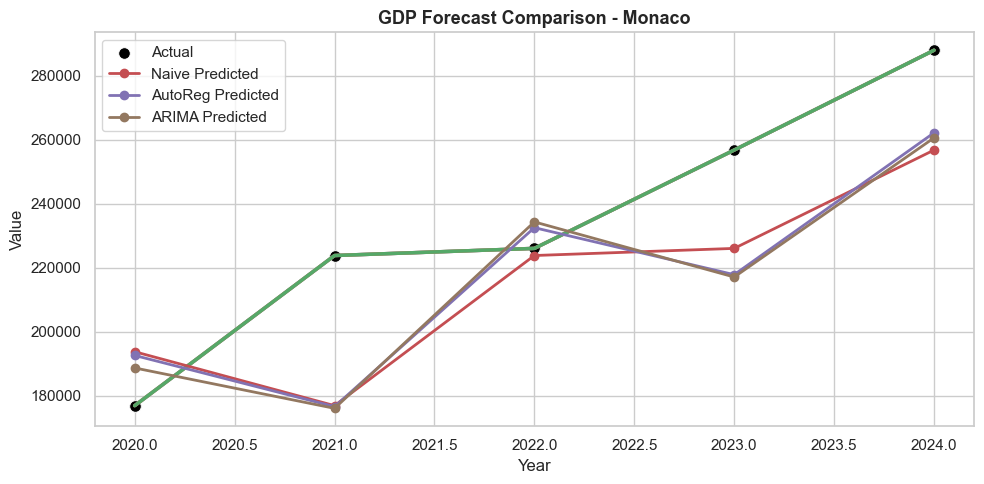

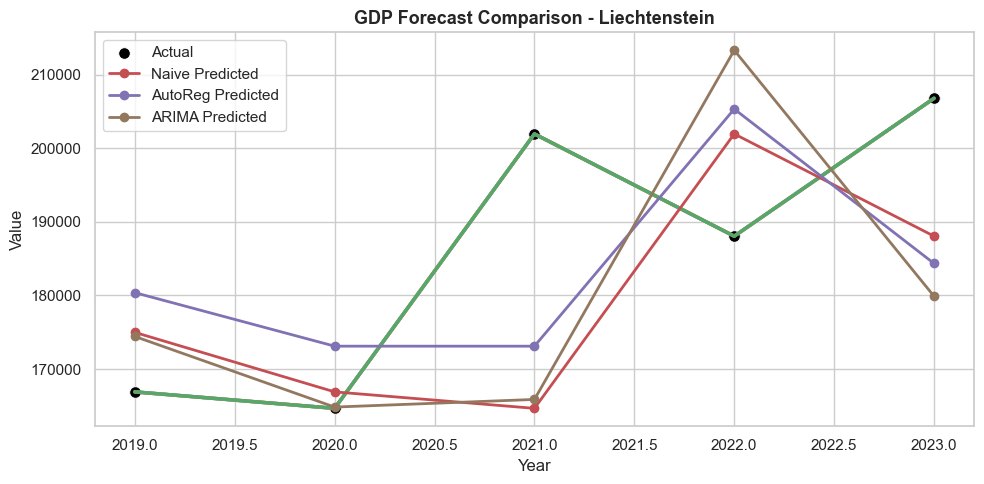

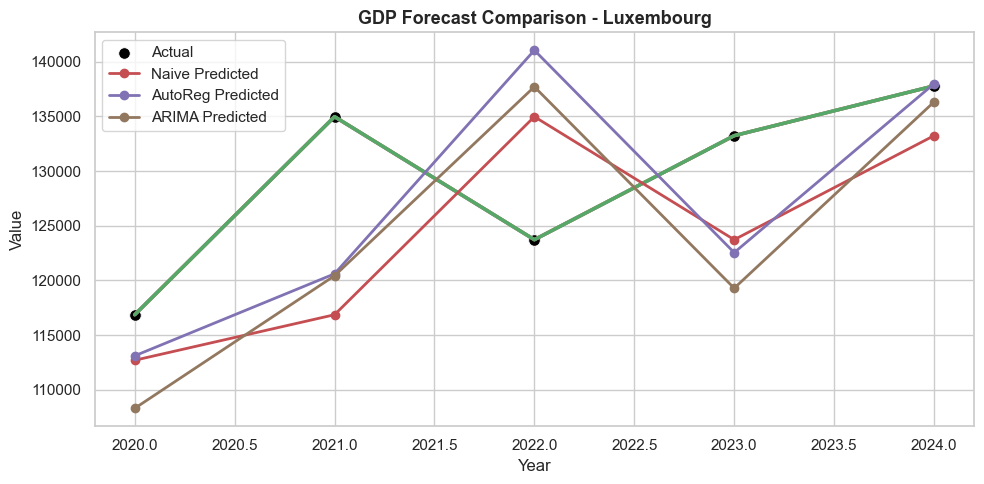

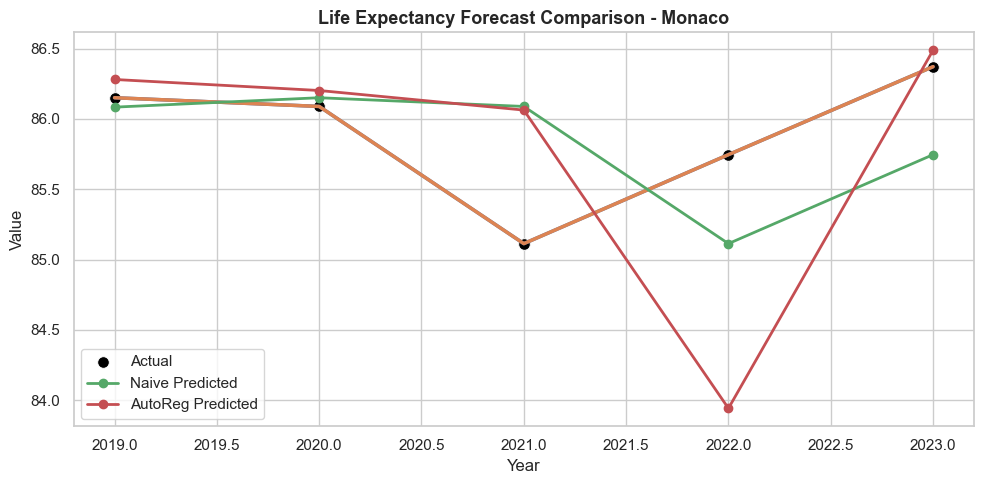

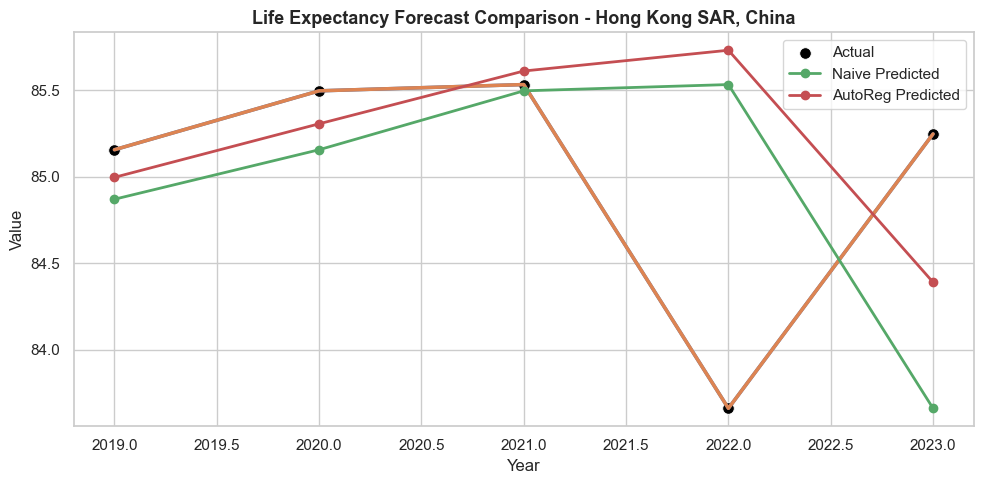

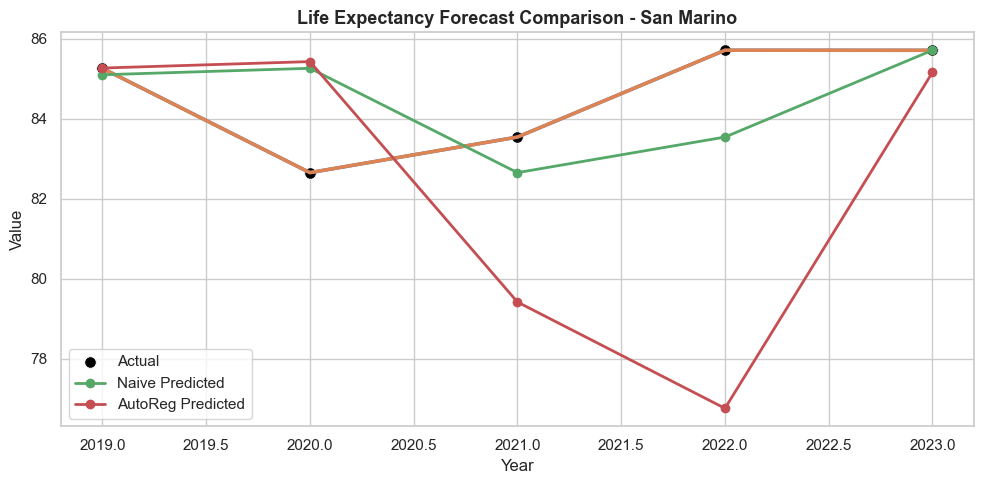

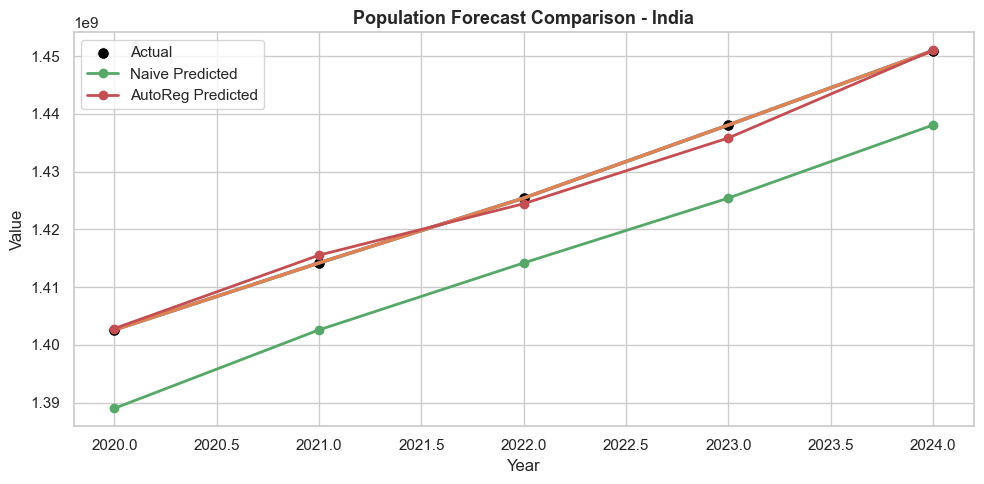

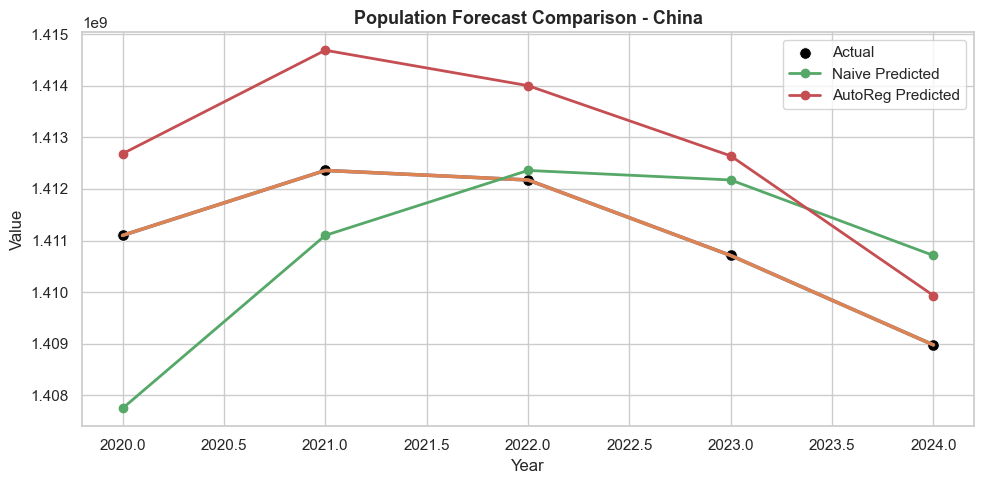

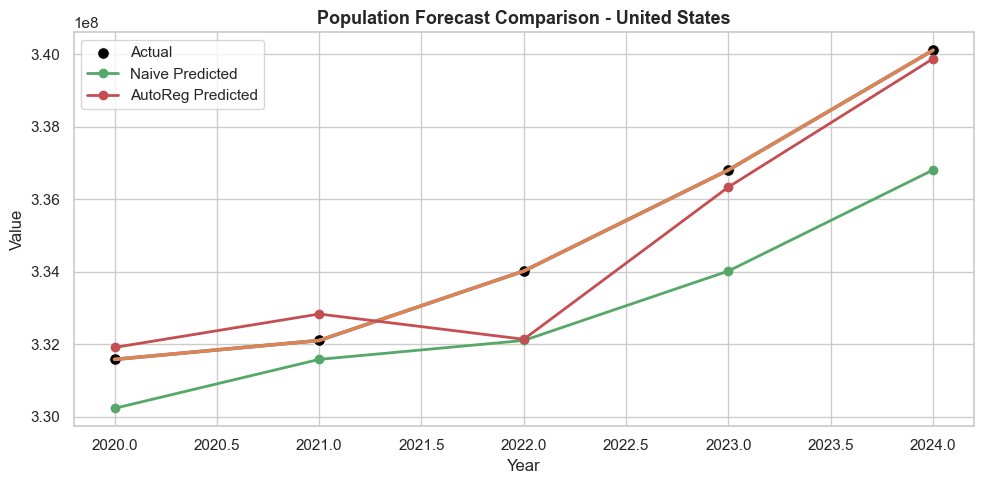

In [14]:
def plot_sample_forecasts(pred_df, dataset_name, top_n=3):
    dataset_df = pred_df[pred_df["Dataset"] == dataset_name].copy()

    sample_keys = (
        dataset_df.groupby(["country_code", "country_name"])["actual"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    for _, row in sample_keys.iterrows():
        country_code = row["country_code"]
        country_name = row["country_name"]

        temp = dataset_df[dataset_df["country_code"] == country_code].copy()

        plt.figure(figsize=(10, 5))
        sns.lineplot(data=temp, x="year", y="actual", hue="Model", legend=False, linewidth=2.5, color="black")
        sns.scatterplot(data=temp, x="year", y="actual", color="black", s=70, label="Actual")

        for model_name in temp["Model"].unique():
            model_temp = temp[temp["Model"] == model_name]
            plt.plot(model_temp["year"], model_temp["predicted"], marker="o", linewidth=2.0, label=f"{model_name} Predicted")

        plt.title(f"{dataset_name} Forecast Comparison - {country_name}", fontsize=13, fontweight="bold")
        plt.xlabel("Year")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_sample_forecasts(all_predictions, "GDP", top_n=3)
plot_sample_forecasts(all_predictions, "Life Expectancy", top_n=3)
plot_sample_forecasts(all_predictions, "Population", top_n=3)
